In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
import json
import numpy as np

loc = Path.cwd()

print(loc)
json_file=[]

c:\Users\mark\OneDrive\文档\GitHub\COMP9517GROUP_SUBJECT\src\performenceCompare


In [10]:
imgNetF = loc / "resNet_data"

# Find and read all JSON files recursively
for file_path in imgNetF.rglob("*.json"):
    print(f"Found: {file_path}")
    json_file.append(file_path)
        



Found: c:\Users\mark\OneDrive\文档\GitHub\COMP9517GROUP_SUBJECT\src\performenceCompare\resNet_data\inat_resnet18_500_npclasses_imagenet_history.json
Found: c:\Users\mark\OneDrive\文档\GitHub\COMP9517GROUP_SUBJECT\src\performenceCompare\resNet_data\inat_resnet18_500_ptclasses_imagenet_history.json
Found: c:\Users\mark\OneDrive\文档\GitHub\COMP9517GROUP_SUBJECT\src\performenceCompare\resNet_data\inat_resnet50_500_npclasses_imagenet_history.json
Found: c:\Users\mark\OneDrive\文档\GitHub\COMP9517GROUP_SUBJECT\src\performenceCompare\resNet_data\inat_resnet50_500_ptclasses_imagenet_history.json


In [11]:
import json

json_data=[]
# Find and read all JSON files recursively
for file_path in json_file:    
    print(file_path.name)
    try:
        # read_text() reads content; json.loads() parses it
        data = json.loads(file_path.read_text(encoding="utf-8"))
        print(data)
        json_data.append(data)
        # Process your data here
    except json.JSONDecodeError:
        print(f"Error: {file_path.name} is not a valid JSON file.")

model_name={"inat_resnet18_500_ptclasses_imagenet_history.json":"ResNet18 pretrained model",
            "inat_resnet50_500_ptclasses_imagenet_history.json":"ResNet50 pretrained model",
            "inat_resnet18_500_npclasses_imagenet_history.json":"ResNet18 random start model",
            "inat_resnet50_500_npclasses_imagenet_history.json":"ResNet50 random start model"
            }

assert len(model_name.keys())==len(json_file)

inat_resnet18_500_npclasses_imagenet_history.json
{'epoch': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44], 'train_loss': [5.986390502929687, 5.58091583480835, 5.345702702331543, 5.147355339050293, 4.9611721496582035, 4.780485903167724, 4.613287899017334, 4.447647068405152, 4.2889707664489745, 4.135824099349976, 4.003001566696167, 3.8661085891723634, 3.732024410247803, 3.6124371295928954, 3.485439996337891, 3.3757812576293946, 3.2481253772735594, 3.1502182498931885, 3.039439995574951, 2.9350683753967286, 2.831083456039429, 2.731025014877319, 2.630516530609131, 2.5208152662277223, 2.4314763866424562, 2.3253455457687378, 2.040007846069336, 1.943442414855957, 1.8906679508209228, 1.824428888130188, 1.768493563270569, 1.638182207107544, 1.5924638833999634, 1.5603504570007325, 1.5389664993286132, 1.476721088218689, 1.4563690814971924, 1.4453138368606568, 1.429659323310852,

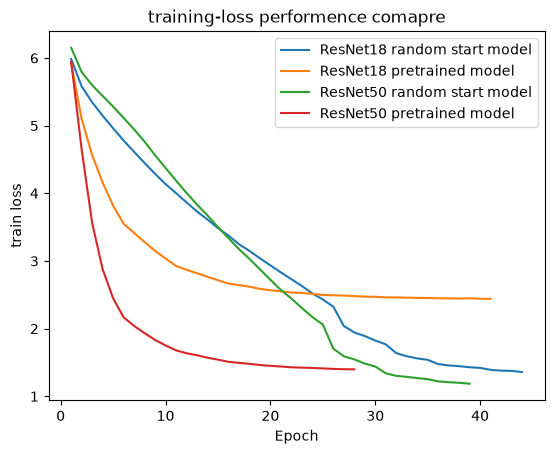

In [12]:
# train loss

for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['train_loss'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("train loss")
plt.title("training-loss performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

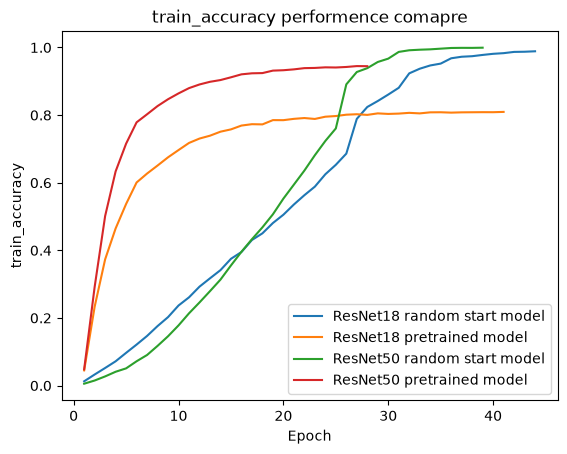

In [13]:
# train acc

for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['train_accuracy'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("train_accuracy")
plt.title("train_accuracy performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

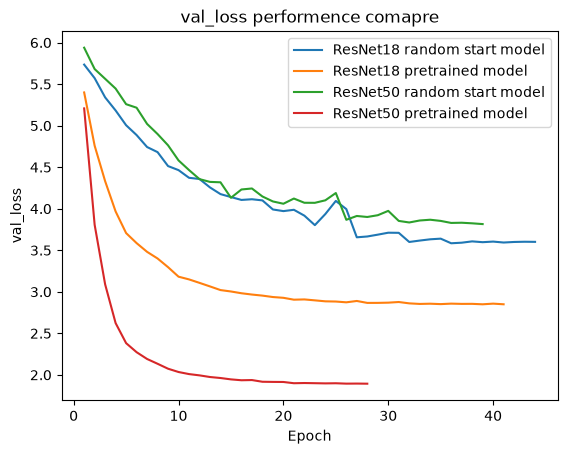

In [14]:
# val loss


for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['val_loss'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("val_loss")
plt.title("val_loss performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

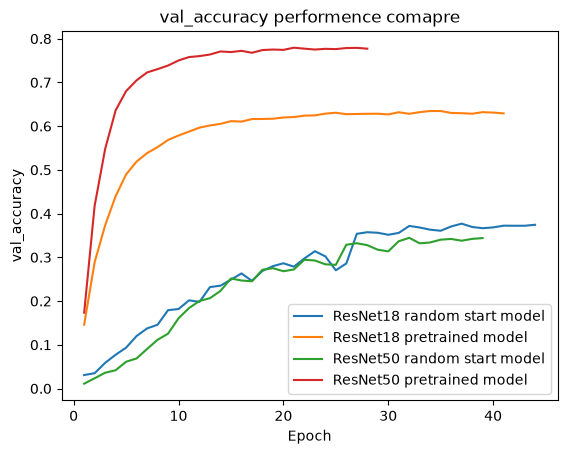

In [15]:
# train acc


for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['val_accuracy'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("val_accuracy")
plt.title("val_accuracy performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

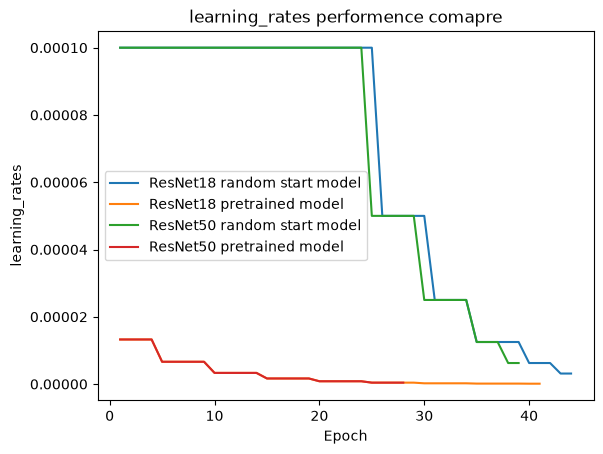

In [ ]:
# learning rate

for dt in range(len(json_data)):
    if type(json_data[dt]['learning_rates'][0]) == list:
        row_averages = [sum(row) / len(row) for row in json_data[dt]['learning_rates']]
        plt.plot(json_data[dt]['epoch'], row_averages, label=model_name[json_file[dt].name], linestyle="-")

    else:
        plt.plot(json_data[dt]['epoch'], json_data[dt]['learning_rates'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("learning_rates")
plt.title("learning_rates performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib